# 02 · Feature Engineering

Runs the feature engineering pipeline in `src/feature_engineering.py` on the full synthetic dataset, producing the repayment, GST-authenticity, cash-flow, bureau, EPFO and text/NLP feature families used for modelling.

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))
import pandas as pd
import matplotlib.pyplot as plt
from feature_engineering import build_features, get_model_feature_columns

raw = pd.read_csv(os.path.join('..', 'data', 'synthetic_msme_data.csv'))
print(raw.shape)
raw.head()

(28000, 65)


,record_id,borrower_id,borrower_name,segment,constitution,sector,geography,business_vintage_years,loan_type,sanctioned_limit,...,credit_vintage_years,epfo_employee_count,epfo_employee_count_change_6m,salary_payment_regularity_score,cam_remarks,fi_remarks,rcu_remarks,collection_remarks,stock_inspection_remarks,stress_12m
0,REC0000000,B100000,MSME Enterprise 00000,Existing,Proprietorship,Food Processing,Mumbai,16.4,Cash Credit,2305988.0,...,13.5,31,-4.7,100.0,adequate liquidity maintained.,unit operational with visible activity.,identity and address cross-verified.,no follow up required this month.,inventory levels healthy and moving; stock age...,0
1,REC0000001,B100000,MSME Enterprise 00000,Existing,Proprietorship,Food Processing,Mumbai,16.4,Cash Credit,2305988.0,...,10.2,4,-5.8,86.5,promoter conduct satisfactory.,unit operations appear scaled down; field inve...,no adverse RCU observation; address verificati...,no follow up required this month.,stock verified and found adequate.,0
2,REC0000002,B100000,MSME Enterprise 00000,Existing,Proprietorship,Food Processing,Mumbai,16.4,Cash Credit,2305988.0,...,14.6,20,-9.3,100.0,repayment track record satisfactory.,field investigation found no adverse observation.,no linkage with other defaulting entities found.,borrower proactively regularised dues.,stock verified and found adequate.,0
3,REC0000003,B100000,MSME Enterprise 00000,Existing,Proprietorship,Food Processing,Mumbai,16.4,Cash Credit,2305988.0,...,15.6,59,0.4,100.0,adequate liquidity maintained.,field investigation found no adverse observation.,documents verified genuine.,borrower proactively regularised dues.,stock verified and found adequate.,0
4,REC0000004,B100000,MSME Enterprise 00000,Existing,Proprietorship,Food Processing,Mumbai,16.4,Cash Credit,2305988.0,...,14.7,16,13.3,79.9,promoter conduct satisfactory.,stock levels found adequate.,no adverse RCU observation.,borrower unreachable on registered number; bor...,stock audit found no discrepancy.,0


## Run the pipeline

In [2]:
engineered, text_artifacts = build_features(raw, fit_text_model=True)
feature_cols = get_model_feature_columns(engineered)
print(f"Engineered shape: {engineered.shape}")
print(f"Model feature columns: {len(feature_cols)}")

Engineered shape: (28000, 97)
Model feature columns: 87


## Repayment features

In [3]:
engineered[['high_dpd_flag','repeated_bounce_flag','dpd_trend_score','repayment_stress_index','stress_12m']].groupby('stress_12m').mean()

,high_dpd_flag,repeated_bounce_flag,dpd_trend_score,repayment_stress_index
stress_12m,,,,
0,0.000497,0.304921,9.829094,13.570016
1,0.218510,0.925520,39.693373,36.700821


## GST authenticity features

In [4]:
engineered[['gst_bank_mismatch_flag','high_itc_flag','gst_delay_flag','turnover_spike_flag',
            'buyer_concentration_flag','gst_authenticity_score','stress_12m']].groupby('stress_12m').mean()

,gst_bank_mismatch_flag,high_itc_flag,gst_delay_flag,turnover_spike_flag,buyer_concentration_flag,gst_authenticity_score
stress_12m,,,,,,
0,0.184725,0.192940,0.097119,0.058799,0.306144,85.178001
1,0.831873,0.857065,0.579956,0.439211,0.928258,38.751807


## Cash-flow features

In [5]:
engineered[['low_surplus_flag','high_cash_deposit_flag','cashflow_volatility_flag',
            'dscr_proxy_flag','cashflow_strength_score','stress_12m']].groupby('stress_12m').mean()

,low_surplus_flag,high_cash_deposit_flag,cashflow_volatility_flag,dscr_proxy_flag,cashflow_strength_score
stress_12m,,,,,
0,0.338657,0.200237,0.186368,0.335677,73.566516
1,0.940854,0.898686,0.901424,0.926068,9.279847


## Bureau & EPFO features

In [6]:
engineered[['bureau_low_score_flag','enquiry_spike_flag','unsecured_exposure_flag','bureau_stress_score',
            'employee_decline_flag','salary_irregularity_flag','operating_stability_score','stress_12m']].groupby('stress_12m').mean()

,bureau_low_score_flag,enquiry_spike_flag,unsecured_exposure_flag,bureau_stress_score,employee_decline_flag,salary_irregularity_flag,operating_stability_score
stress_12m,,,,,,,
0,0.276916,0.196302,0.239512,20.082830,0.273592,0.186636,77.222805
1,0.947426,0.860350,0.912924,77.859036,0.937021,0.911829,13.262924


## Text / NLP features

Keyword-based counts/flags plus a first-stage TF-IDF + Logistic Regression text risk model.

In [7]:
engineered[['risk_keyword_count','positive_keyword_count','text_risk_score','fraud_keyword_flag',
            'business_stress_keyword_flag','text_model_risk_score','stress_12m']].groupby('stress_12m').mean()

,risk_keyword_count,positive_keyword_count,text_risk_score,fraud_keyword_flag,business_stress_keyword_flag,text_model_risk_score
stress_12m,,,,,,
0,2.27619,3.295026,36.138229,0.371934,0.477191,22.104073
1,6.94414,2.295728,91.657722,0.865279,0.933735,77.907338


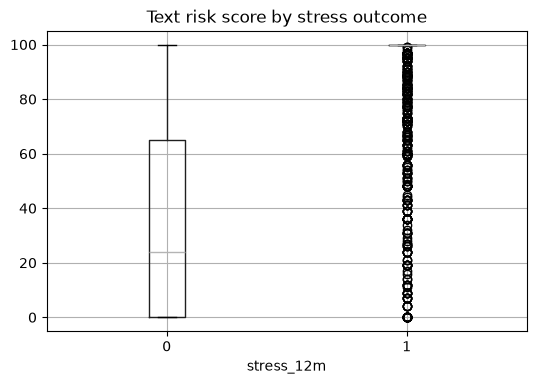

In [8]:
fig, ax = plt.subplots(figsize=(6,4))
engineered.boxplot(column='text_risk_score', by='stress_12m', ax=ax)
plt.suptitle('')
plt.title('Text risk score by stress outcome')
plt.show()

## Next step

Proceed to `03_model_training_evaluation.ipynb`.